# Training Dataset Bahasa Isyarat menggunakan CNN + LSTM (PyTorch)

Versi PyTorch dari `CNN_LSTM_independent_dataset.ipynb`. Notebook ini mempertahankan preprocessing, augmentasi, pembagian dataset, evaluasi, dan checkpoint model dengan loop training PyTorch.

In [1]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

2.14.0+cu130
13.0
True
NVIDIA GeForce RTX 4070 Ti


In [2]:
from pathlib import Path
import copy
import json
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.14.0+cu130
Device: cuda


## 1.1. Setting PyTorch GPU

In [3]:
print("CUDA tersedia:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA tersedia: True
GPU: NVIDIA GeForce RTX 4070 Ti


# 2. Setup OpenCV dan Mediapipe HandLandmarker

## 2.1. Inisialisasi Mediapipe HandLandmarker

Landmark sudah diproses menjadi file `.npy`, sehingga cell berikut hanya dokumentasi setup yang sama dengan notebook sumber.

In [4]:
# Opsional untuk ekstraksi landmark baru:
# import mediapipe as mp
# from mediapipe.tasks import python
# from mediapipe.tasks.python import vision
# BaseOptions = mp.tasks.BaseOptions
# HandLandmarker = mp.tasks.vision.HandLandmarker
# HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
# VisionRunningMode = mp.tasks.vision.RunningMode

In [5]:
# options = HandLandmarkerOptions(
#     base_options=BaseOptions(model_asset_path='handlandmarker/hand_landmarker.task'),
#     running_mode=VisionRunningMode.IMAGE,
#     num_hands=2,
# )

In [6]:
# def mediapipe_detection(image, model):
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     image.flags.writeable = False
#     results = model.detect(image)
#     image.flags.writeable = True
#     image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
#     return image, results

In [7]:
# Cell kosong pada notebook sumber, dipertahankan sebagai pemisah prosedur.

## 2.2. Inisialisasi OpenCV

In [8]:
# Contoh capture kamera Linux untuk ekstraksi dataset baru:
# cap = cv2.VideoCapture(0, cv2.CAP_V4L2)
# if not cap.isOpened():
#     print("Cannot open camera")
# cap.release()
# cv2.destroyAllWindows()

In [9]:
# Cell kosong pada notebook sumber, dipertahankan sebagai pemisah prosedur.

# 3. Import Dataset

## 1. Konfigurasi Dataset

In [10]:
PROJECT_DIR = Path("/home/raddief/Project/Despro/Despro-BIDISGN")
DATA_PATH = PROJECT_DIR / "dataset"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset tidak ditemukan: {DATA_PATH.resolve()}")

# 4. Preprocessing Dataset

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

VIDEO_FRAMES = 90
FEATURES = 126
BATCH_SIZE = 32
EPOCHS = 150
PATIENCE = 15
NUM_WORKERS = 0

In [12]:
actions = np.array(sorted([path.name for path in DATA_PATH.iterdir() if path.is_dir()]))
label_map = {label: index for index, label in enumerate(actions)}

In [13]:
print("Daftar actions:", actions)
print("Label map:", label_map)

Daftar actions: ['A' 'Aku' 'Anda' 'Apa' 'B' 'Baik' 'Berapa' 'Bodoh' 'C' 'D' 'Darimana'
 'Dimana' 'E' 'F' 'G' 'H' 'Hallo' 'I' 'J' 'K' 'Kalian' 'Kamu' 'Kemana'
 'Kenapa' 'Kita' 'L' 'M' 'N' 'Nunggu' 'O' 'P' 'Pintar' 'Q' 'R' 'S' 'Saya'
 'Semua' 'Siapa' 'Sombong' 'Sudah' 'T' 'Terima Kasih' 'U' 'V' 'W' 'X' 'Y'
 'Z']
Label map: {np.str_('A'): 0, np.str_('Aku'): 1, np.str_('Anda'): 2, np.str_('Apa'): 3, np.str_('B'): 4, np.str_('Baik'): 5, np.str_('Berapa'): 6, np.str_('Bodoh'): 7, np.str_('C'): 8, np.str_('D'): 9, np.str_('Darimana'): 10, np.str_('Dimana'): 11, np.str_('E'): 12, np.str_('F'): 13, np.str_('G'): 14, np.str_('H'): 15, np.str_('Hallo'): 16, np.str_('I'): 17, np.str_('J'): 18, np.str_('K'): 19, np.str_('Kalian'): 20, np.str_('Kamu'): 21, np.str_('Kemana'): 22, np.str_('Kenapa'): 23, np.str_('Kita'): 24, np.str_('L'): 25, np.str_('M'): 26, np.str_('N'): 27, np.str_('Nunggu'): 28, np.str_('O'): 29, np.str_('P'): 30, np.str_('Pintar'): 31, np.str_('Q'): 32, np.str_('R'): 33, np.str_(

## 4.1. Augmentasi Dataset

In [14]:
def augment_sequence(sequence):
    # sequence shape: (90, 126)
    # 126 = 2 tangan x 21 landmark x 3 koordinat
    num_frames = sequence.shape[0]

    # Ubah menjadi:
    # (frames, landmarks, coordinates)
    sequence_reshaped = sequence.reshape(num_frames, 42, 3)

    # Cek landmark yang benar-benar memiliki koordinat
    # shape: (frames, 42, 1)
    valid_landmarks = (
        np.abs(sequence_reshaped).sum(axis=2, keepdims=True) > 0
    ).astype(np.float32)

    # Kembalikan mask ke shape asli (90, 126)
    valid_landmarks = np.repeat(valid_landmarks, 3, axis=2)
    valid_landmarks = valid_landmarks.reshape(sequence.shape)

    augmented_sequences = []

    # 1. Gaussian noise kecil
    noise1 = np.random.normal(
        0, 0.02, sequence.shape
    ).astype(np.float32)

    augmented_sequences.append(
        sequence + noise1 * valid_landmarks
    )

    # 2. Gaussian noise sedikit lebih besar
    noise2 = np.random.normal(
        0, 0.035, sequence.shape
    ).astype(np.float32)

    augmented_sequences.append(
        sequence + noise2 * valid_landmarks
    )

    # 3. Scaling mengecilkan
    augmented_sequences.append(
        sequence * np.random.uniform(0.90, 0.97)
    )

    # 4. Scaling membesarkan
    augmented_sequences.append(
        sequence * np.random.uniform(1.03, 1.10)
    )

    # 5. Kombinasi noise + scaling
    noise3 = np.random.normal(
        0, 0.025, sequence.shape
    ).astype(np.float32)

    augmented_sequences.append(
        (sequence + noise3 * valid_landmarks)
        * np.random.uniform(0.92, 1.08)
    )

    return augmented_sequences

In [15]:
def resample_sequence(sequence, target_frames):
    if sequence.shape[0] == target_frames:
        return sequence.astype(np.float32)

    source_positions = np.linspace(0.0, 1.0, sequence.shape[0])
    target_positions = np.linspace(0.0, 1.0, target_frames)
    resampled = np.empty((target_frames, sequence.shape[1]), dtype=np.float32)
    for feature_index in range(sequence.shape[1]):
        resampled[:, feature_index] = np.interp(
            target_positions,
            source_positions,
            sequence[:, feature_index],
        )
    return resampled


def normalize_sequence(sequence):
    normalized = sequence.reshape(sequence.shape[0], 2, 21, 3).copy()
    for hand_index in range(2):
        hand = normalized[:, hand_index]
        valid_frames = np.abs(hand).sum(axis=(1, 2)) > 0
        if not np.any(valid_frames):
            continue

        wrist = hand[:, :1, :].copy()
        hand -= wrist
        scale = np.linalg.norm(hand, axis=2).max(axis=1, keepdims=True)
        scale = np.where(scale > 1e-6, scale, 1.0)
        hand /= scale[:, :, None]
        normalized[~valid_frames, hand_index] = 0.0

    return normalized.reshape(sequence.shape).astype(np.float32)


# ==============================================================
# Load & Augment SEMUA data SEBELUM split (sesuai Keras notebook)
# ==============================================================

sequences_raw, labels_raw = [], []

for action in actions:
    action_path = DATA_PATH / action
    npy_files = sorted(action_path.glob("*.npy"))
    for npy_file in npy_files:
        sequence = np.asarray(np.load(npy_file), dtype=np.float32)
        if sequence.ndim != 2 or sequence.shape[1] != FEATURES:
            raise ValueError(f"Shape tidak valid pada {npy_file}: {sequence.shape}")
        sequence = resample_sequence(sequence, VIDEO_FRAMES)
        sequence = normalize_sequence(sequence)

        # --- Augmentasi sebelum split (mirip Keras notebook) ---
        # 1. Tambahkan data original
        sequences_raw.append(sequence)
        labels_raw.append(label_map[action])

        # 2. Augmentasi + tambahkan 5 versi buatan
        for aug_seq in augment_sequence(sequence):
            sequences_raw.append(aug_seq.astype(np.float32))
            labels_raw.append(label_map[action])

X_all = np.asarray(sequences_raw, dtype=np.float32)
y_all = np.asarray(labels_raw, dtype=np.int64)

print(f"Total data setelah augmentasi: {X_all.shape} -> {y_all.shape}")

# --- Split: 60% train, 20% dev, 20% test ---
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED
)

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Dev:   {X_dev.shape}, {y_dev.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

Total data setelah augmentasi: (7020, 90, 126) -> (7020,)
Train: (4212, 90, 126), (4212,)
Dev:   (1404, 90, 126), (1404,)
Test:  (1404, 90, 126), (1404,)


In [16]:
class SignLanguageDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.from_numpy(features).float()
        self.labels = torch.from_numpy(labels).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]


def make_loader(features, labels, shuffle):
    return DataLoader(
        SignLanguageDataset(features, labels),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=device.type == "cuda",
    )

train_loader = make_loader(X_train, y_train, shuffle=True)
dev_loader = make_loader(X_dev, y_dev, shuffle=False)
test_loader = make_loader(X_test, y_test, shuffle=False)

# 5. Training Base Model

## 5.1. Definisikan Arsitektur CNN + LSTM

In [17]:
class CNNLSTM(nn.Module):
    def __init__(
        self,
        num_classes,
        filters_1=64,
        filters_2=64,
        lstm_1=64,
        lstm_2=64,
        lstm_3=64,
        dense_1=64,
        dense_2=32,
        dropout=0.2,
    ):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(FEATURES, filters_1, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
            nn.Conv1d(filters_1, filters_2, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(filters_2, lstm_1, batch_first=True)
        self.lstm_2 = nn.LSTM(lstm_1, lstm_2, batch_first=True)
        self.lstm_3 = nn.LSTM(lstm_2, lstm_3, batch_first=True)
        self.temporal_dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_3, dense_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dense_1, dense_2),
            nn.ReLU(),
            nn.Linear(dense_2, num_classes),
        )

    def forward(self, inputs):
        features = self.cnn(inputs.transpose(1, 2)).transpose(1, 2)
        features, _ = self.lstm(features)
        features = self.temporal_dropout(torch.relu(features))
        features, _ = self.lstm_2(features)
        features = self.temporal_dropout(torch.relu(features))
        features, _ = self.lstm_3(features)
        features = self.temporal_dropout(torch.relu(features))
        return self.classifier(features[:, -1])


model = CNNLSTM(num_classes=len(actions)).to(device)
print(model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(126, 64, kernel_size=(3,), stride=(1,), padding=same)
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
  )
  (lstm): LSTM(64, 64, batch_first=True)
  (lstm_2): LSTM(64, 64, batch_first=True)
  (lstm_3): LSTM(64, 64, batch_first=True)
  (temporal_dropout): Dropout(p=0.2, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=48, bias=True)
  )
)


In [18]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_correct = 0
    total_items = 0

    with torch.set_grad_enabled(is_training):
        for features, targets in loader:
            features, targets = features.to(device), targets.to(device)
            logits = model(features)
            loss = criterion(logits, targets)

            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_items += targets.size(0)

    return total_loss / total_items, total_correct / total_items


def fit_model(
    model,
    train_loader,
    dev_loader,
    epochs=EPOCHS,
    patience=PATIENCE,
    learning_rate=1e-4,
    weight_decay=1e-4,
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    history = {"train_loss": [], "dev_loss": [], "train_accuracy": [], "dev_accuracy": []}
    best_state = copy.deepcopy(model.state_dict())
    best_loss = float("inf")
    stale_epochs = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = run_epoch(model, train_loader, criterion, optimizer)
        dev_loss, dev_accuracy = run_epoch(model, dev_loader, criterion)
        history["train_loss"].append(train_loss)
        history["dev_loss"].append(dev_loss)
        history["train_accuracy"].append(train_accuracy)
        history["dev_accuracy"].append(dev_accuracy)

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"train loss {train_loss:.4f}, acc {train_accuracy:.4f} | "
            f"dev loss {dev_loss:.4f}, acc {dev_accuracy:.4f}"
        )
        if dev_loss < best_loss:
            best_loss = dev_loss
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print("Early stopping")
                break

    model.load_state_dict(best_state)
    return history

## 5.2. Melakukan Training

In [19]:
base_model = CNNLSTM(num_classes=len(actions)).to(device)
history = fit_model(base_model, train_loader, dev_loader)

Epoch 001/150 | train loss 3.8662, acc 0.0496 | dev loss 3.8610, acc 0.0527
Epoch 002/150 | train loss 3.8552, acc 0.0496 | dev loss 3.8442, acc 0.0527
Epoch 003/150 | train loss 3.7855, acc 0.0525 | dev loss 3.7080, acc 0.0548
Epoch 004/150 | train loss 3.6502, acc 0.0515 | dev loss 3.5375, acc 0.0520
Epoch 005/150 | train loss 3.4999, acc 0.0518 | dev loss 3.4202, acc 0.0527
Epoch 006/150 | train loss 3.4295, acc 0.0470 | dev loss 3.3711, acc 0.0520
Epoch 007/150 | train loss 3.3920, acc 0.0693 | dev loss 3.3409, acc 0.0976
Epoch 008/150 | train loss 3.3293, acc 0.0995 | dev loss 3.2237, acc 0.0997
Epoch 009/150 | train loss 3.1766, acc 0.1014 | dev loss 3.0704, acc 0.1004
Epoch 010/150 | train loss 3.0686, acc 0.1038 | dev loss 3.0106, acc 0.1004
Epoch 011/150 | train loss 3.0273, acc 0.1045 | dev loss 2.9899, acc 0.1004
Epoch 012/150 | train loss 3.0009, acc 0.1156 | dev loss 2.9599, acc 0.1075
Epoch 013/150 | train loss 2.9727, acc 0.1218 | dev loss 2.9327, acc 0.1489
Epoch 014/15

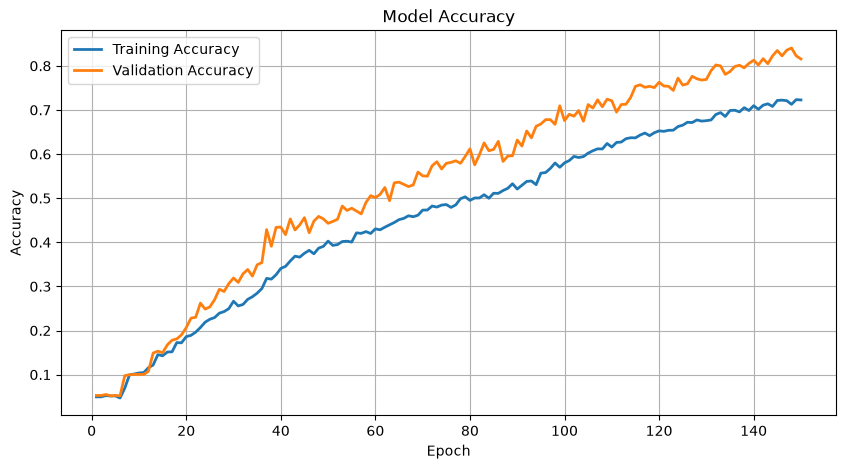

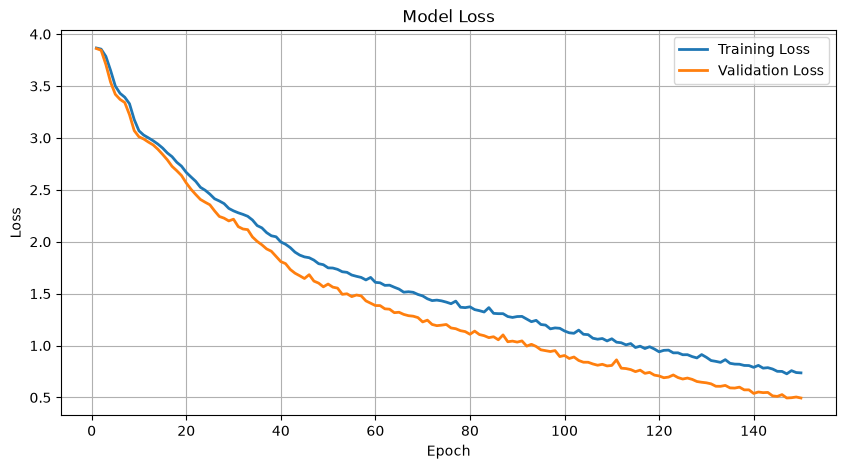

Final Training Accuracy:  0.7227
Final Validation Accuracy: 0.8155
Final Training Loss:       0.7370
Final Validation Loss:     0.4950


In [20]:
acc = history["train_accuracy"]
val_acc = history["dev_accuracy"]
loss = history["train_loss"]
val_loss = history["dev_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, label="Training Accuracy", linewidth=2)
plt.plot(epochs, val_acc, label="Validation Accuracy", linewidth=2)
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, label="Training Loss", linewidth=2)
plt.plot(epochs, val_loss, label="Validation Loss", linewidth=2)
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Training Accuracy:  {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Final Training Loss:       {loss[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss[-1]:.4f}")

## 5.3. Analisis dan Evaluasi Base Model

================ Evaluasi Base Model ================
              precision    recall  f1-score   support

           A       0.67      0.19      0.30        21
         Aku       0.00      0.00      0.00        15
        Anda       1.00      0.92      0.96        24
         Apa       1.00      1.00      1.00        86
           B       0.39      0.58      0.47        12
        Baik       0.50      0.15      0.23        20
      Berapa       0.83      1.00      0.91        10
       Bodoh       1.00      1.00      1.00        13
           C       0.87      0.83      0.85        24
           D       0.17      0.19      0.18        16
    Darimana       1.00      1.00      1.00        21
      Dimana       0.98      1.00      0.99        84
           E       0.00      0.00      0.00        19
           F       1.00      0.57      0.73        21
           G       1.00      0.75      0.86        20
           H       0.76      0.89      0.82        18
       Hallo       1.00    

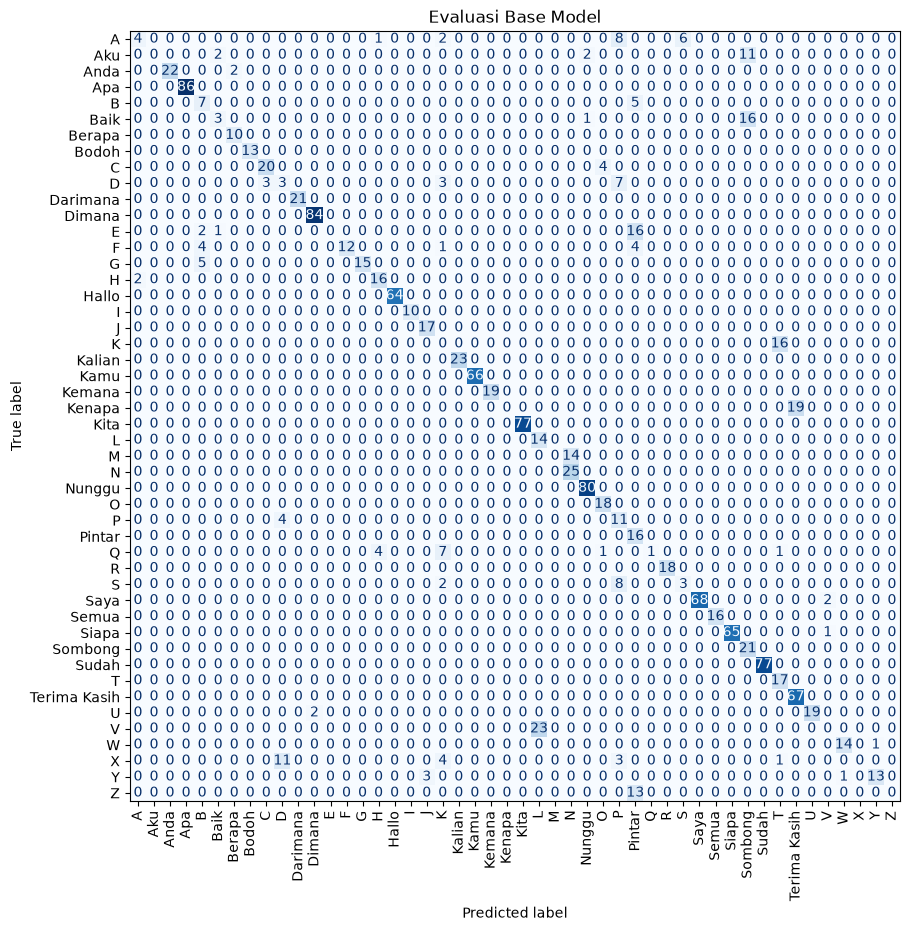

In [21]:
def predict(model, loader):
    model.eval()
    predictions, targets = [], []
    with torch.no_grad():
        for features, batch_targets in loader:
            logits = model(features.to(device))
            predictions.extend(logits.argmax(dim=1).cpu().numpy())
            targets.extend(batch_targets.numpy())
    return np.asarray(targets), np.asarray(predictions)


def evaluate_model(model, loader, title):
    y_true, y_pred = predict(model, loader)
    print(f"================ {title} ================")
    print(classification_report(
        y_true, y_pred, labels=np.arange(len(actions)), target_names=actions, zero_division=0
    ))
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(actions)))
    fig, ax = plt.subplots(figsize=(12, 10))
    ConfusionMatrixDisplay(cm, display_labels=actions).plot(
        cmap=plt.cm.Blues, ax=ax, xticks_rotation="vertical", colorbar=False
    )
    ax.set_title(title)
    plt.show()
    return y_true, y_pred


y_true_base, y_pred_base = evaluate_model(base_model, test_loader, "Evaluasi Base Model")

In [22]:
criterion = nn.CrossEntropyLoss()
test_loss, test_accuracy = run_epoch(base_model, test_loader, criterion)
print("Mengevaluasi model pada Test Set...")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

Mengevaluasi model pada Test Set...
Test Loss     : 0.5036
Test Accuracy : 0.8226 (82.26%)


## 5.4. Simpan Base Model

In [23]:
MODEL_DIR = Path("base_model")
MODEL_DIR.mkdir(exist_ok=True)
base_checkpoint = MODEL_DIR / "model_cnn_lstm_isyarat.pt"

torch.save(
    {
        "model_state_dict": base_model.state_dict(),
        "model_config": {
            "filters_1": 64,
            "filters_2": 64,
            "lstm_1": 64,
            "lstm_2": 64,
            "lstm_3": 64,
            "dense_1": 64,
            "dense_2": 32,
            "dropout": 0.2
        },
        "actions": actions.tolist(),
        "video_frames": VIDEO_FRAMES,
        "features": FEATURES,
    },
    base_checkpoint,
)
print(f"Base model disimpan di {base_checkpoint}")

Base model disimpan di base_model/model_cnn_lstm_isyarat.pt


# 6. Hyperparameter Tuning

## 6.1. Setup Tuner

In [24]:
def sample_hyperparameters():
    return {
        "filters_1": random.choice([32, 64, 96, 128]),
        "filters_2": random.choice([32, 64, 96, 128]),
        "lstm_1": random.choice([32, 64, 96, 128]),
        "lstm_2": random.choice([32, 64, 96, 128]),
        "lstm_3": random.choice([64, 128, 192, 256]),
        "dense_1": random.choice([32, 64, 96, 128]),
        "dense_2": random.choice([32, 64, 96, 128]),
        "dropout": random.choice([0.2, 0.3, 0.4]),
    }


MAX_TRIALS = 100
TUNING_EPOCHS = 100
trial_results = []

## 6.2. Melakukan Hyperparameter Tuning

In [25]:
def format_elapsed(seconds):
    seconds = int(seconds)
    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{hours:02d}h {minutes:02d}m {seconds:02d}s"


MAX_TRIALS = 100
TUNING_EPOCHS = 100
trial_results = []

tuning_start = time.perf_counter()
best_val_accuracy = 0.0

for trial_index in range(1, MAX_TRIALS + 1):
    trial_start = time.perf_counter()

    config = sample_hyperparameters()
    trial_model = CNNLSTM(
        num_classes=len(actions),
        **config,
    ).to(device)
    trial_history = fit_model(
        trial_model,
        train_loader,
        dev_loader,
        epochs=TUNING_EPOCHS,
        patience=PATIENCE,
        learning_rate=1e-4,
    )

    trial_val_accuracy = max(trial_history["dev_accuracy"])
    trial_results.append({
        "config": config,
        "dev_accuracy": trial_val_accuracy,
    })

    best_val_accuracy = max(best_val_accuracy, trial_val_accuracy)
    trial_elapsed = time.perf_counter() - trial_start
    total_elapsed = time.perf_counter() - tuning_start
    average_trial_time = total_elapsed / trial_index
    remaining_time = average_trial_time * (MAX_TRIALS - trial_index)

    print(f"\nTrial {trial_index} Complete [{format_elapsed(trial_elapsed)}]")
    print(f"val_categorical_accuracy: {trial_val_accuracy:.6f}")
    print()
    print(f"Best val_categorical_accuracy So Far: {best_val_accuracy:.6f}")
    print(f"Total elapsed time: {format_elapsed(total_elapsed)}")
    print(f"Estimated remaining time: {format_elapsed(remaining_time)}")

Epoch 001/100 | train loss 3.8649, acc 0.0340 | dev loss 3.8555, acc 0.0584
Epoch 002/100 | train loss 3.8226, acc 0.0487 | dev loss 3.7283, acc 0.0584
Epoch 003/100 | train loss 3.7184, acc 0.0489 | dev loss 3.6671, acc 0.0584
Epoch 004/100 | train loss 3.6134, acc 0.0456 | dev loss 3.4766, acc 0.0919
Epoch 005/100 | train loss 3.4344, acc 0.0468 | dev loss 3.3343, acc 0.0456
Epoch 006/100 | train loss 3.3535, acc 0.0601 | dev loss 3.2852, acc 0.0783
Epoch 007/100 | train loss 3.2885, acc 0.0869 | dev loss 3.2326, acc 0.1125
Epoch 008/100 | train loss 3.2652, acc 0.0992 | dev loss 3.2005, acc 0.1268
Epoch 009/100 | train loss 3.2336, acc 0.1130 | dev loss 3.2428, acc 0.1353
Epoch 010/100 | train loss 3.1610, acc 0.1239 | dev loss 3.0363, acc 0.1588
Epoch 011/100 | train loss 3.0691, acc 0.1344 | dev loss 2.9466, acc 0.1631
Epoch 012/100 | train loss 3.0092, acc 0.1320 | dev loss 2.8851, acc 0.1667
Epoch 013/100 | train loss 2.9488, acc 0.1396 | dev loss 2.8314, acc 0.1667
Epoch 014/10

In [26]:
best_trial = max(trial_results, key=lambda result: result["dev_accuracy"])
best_config = best_trial["config"]
print("=== Pencarian Selesai! ===")
print("Kombinasi Hyperparameter Terbaik Ditemukan:")
print(best_config)
print(f"Best Dev Accuracy: {best_trial['dev_accuracy']:.4f}")

=== Pencarian Selesai! ===
Kombinasi Hyperparameter Terbaik Ditemukan:
{'filters_1': 96, 'filters_2': 64, 'lstm_1': 96, 'lstm_2': 64, 'lstm_3': 256, 'dense_1': 128, 'dense_2': 32, 'dropout': 0.2}
Best Dev Accuracy: 0.9509


In [27]:
print("Me-retrain model terbaik...")
tuned_model = CNNLSTM(num_classes=len(actions), **best_config).to(device)
tuned_history = fit_model(tuned_model, train_loader, dev_loader)

Me-retrain model terbaik...
Epoch 001/150 | train loss 3.8547, acc 0.0283 | dev loss 3.7686, acc 0.0584
Epoch 002/150 | train loss 3.7383, acc 0.0503 | dev loss 3.6767, acc 0.0584
Epoch 003/150 | train loss 3.6921, acc 0.0506 | dev loss 3.6307, acc 0.0584
Epoch 004/150 | train loss 3.4436, acc 0.0553 | dev loss 3.2860, acc 0.0548
Epoch 005/150 | train loss 3.2822, acc 0.0712 | dev loss 3.2134, acc 0.0840
Epoch 006/150 | train loss 3.2134, acc 0.0947 | dev loss 3.1346, acc 0.0912
Epoch 007/150 | train loss 3.1340, acc 0.1002 | dev loss 3.0960, acc 0.1225
Epoch 008/150 | train loss 3.0780, acc 0.1102 | dev loss 3.0211, acc 0.1232
Epoch 009/150 | train loss 3.0194, acc 0.1327 | dev loss 2.9573, acc 0.1809
Epoch 010/150 | train loss 2.9320, acc 0.1567 | dev loss 2.8412, acc 0.1631
Epoch 011/150 | train loss 2.8192, acc 0.1747 | dev loss 2.7051, acc 0.2123
Epoch 012/150 | train loss 2.7228, acc 0.2018 | dev loss 2.6224, acc 0.2343
Epoch 013/150 | train loss 2.6303, acc 0.2047 | dev loss 2.5

## 6.3. Analisis Model Terbaik Setelah Tuning

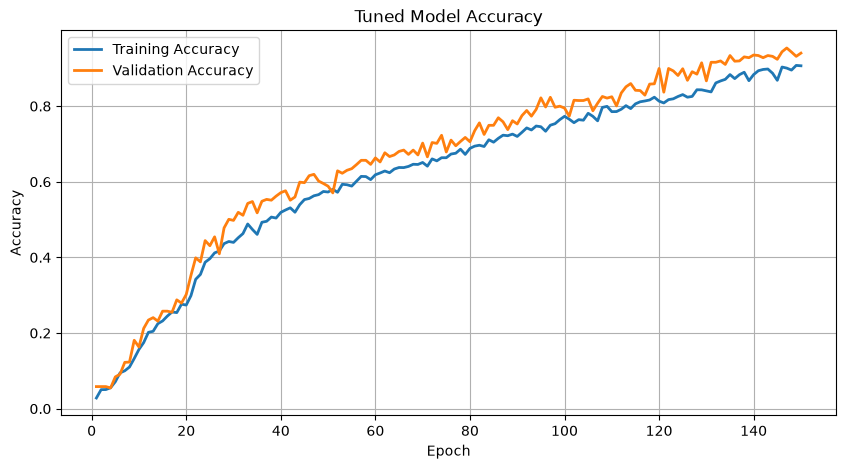

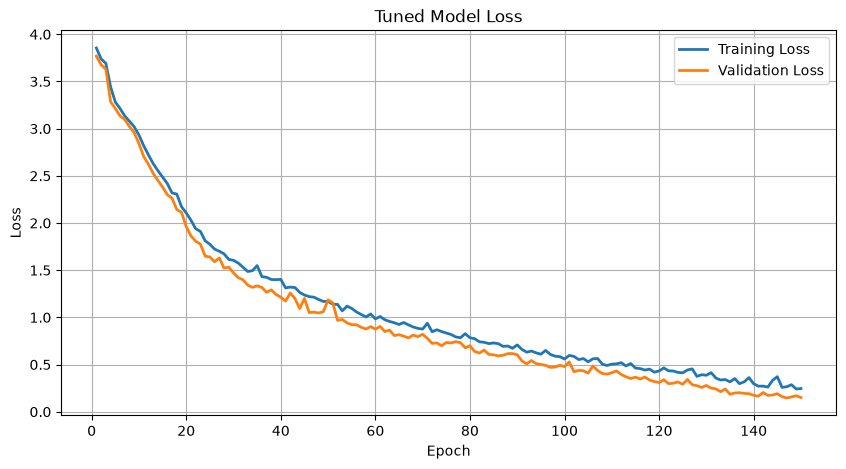

Final Training Accuracy:  0.9067
Final Validation Accuracy: 0.9402
Final Training Loss:       0.2460
Final Validation Loss:     0.1505


In [28]:
acc_tuned = tuned_history["train_accuracy"]
val_acc_tuned = tuned_history["dev_accuracy"]
loss_tuned = tuned_history["train_loss"]
val_loss_tuned = tuned_history["dev_loss"]
epochs_tuned = range(1, len(acc_tuned) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_tuned, acc_tuned, label="Training Accuracy", linewidth=2)
plt.plot(epochs_tuned, val_acc_tuned, label="Validation Accuracy", linewidth=2)
plt.title("Tuned Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_tuned, loss_tuned, label="Training Loss", linewidth=2)
plt.plot(epochs_tuned, val_loss_tuned, label="Validation Loss", linewidth=2)
plt.title("Tuned Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Training Accuracy:  {acc_tuned[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc_tuned[-1]:.4f}")
print(f"Final Training Loss:       {loss_tuned[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss_tuned[-1]:.4f}")

================ Confusion Matrix Model Setelah Hyperparameter Tuning ================
              precision    recall  f1-score   support

           A       0.76      0.90      0.83        21
         Aku       1.00      1.00      1.00        15
        Anda       1.00      1.00      1.00        24
         Apa       1.00      0.98      0.99        86
           B       0.92      1.00      0.96        12
        Baik       1.00      1.00      1.00        20
      Berapa       0.83      1.00      0.91        10
       Bodoh       1.00      1.00      1.00        13
           C       0.96      1.00      0.98        24
           D       0.64      0.44      0.52        16
    Darimana       1.00      1.00      1.00        21
      Dimana       1.00      1.00      1.00        84
           E       1.00      1.00      1.00        19
           F       0.71      0.71      0.71        21
           G       1.00      0.95      0.97        20
           H       1.00      0.94      0.97     

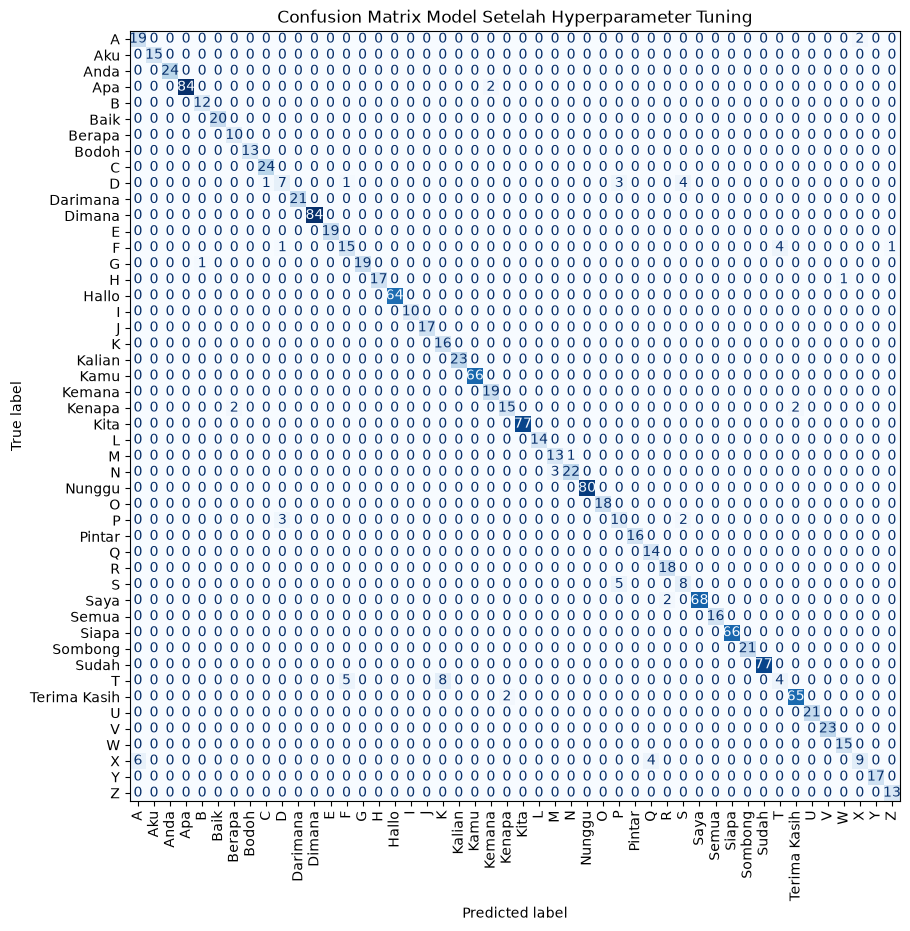

Mengevaluasi model tuned pada Test Set...
Test Loss     : 0.1492
Test Accuracy : 0.9530 (95.30%)


In [29]:
y_true_tuned, y_pred_tuned = evaluate_model(
    tuned_model,
    test_loader,
    "Confusion Matrix Model Setelah Hyperparameter Tuning",
)
criterion = nn.CrossEntropyLoss()
tuned_test_loss, tuned_test_accuracy = run_epoch(tuned_model, test_loader, criterion)
print("Mengevaluasi model tuned pada Test Set...")
print(f"Test Loss     : {tuned_test_loss:.4f}")
print(f"Test Accuracy : {tuned_test_accuracy:.4f} ({tuned_test_accuracy * 100:.2f}%)")

## 6.4. Simpan Model Terbaik

In [30]:
BEST_MODEL_DIR = Path("best_model")
BEST_MODEL_DIR.mkdir(exist_ok=True)
best_checkpoint = BEST_MODEL_DIR / "model_cnn_lstm_isyarat.pt"
torch.save(
    {
        "model_state_dict": tuned_model.state_dict(),
        "model_config": best_config,
        "actions": actions.tolist(),
        "video_frames": VIDEO_FRAMES,
        "features": FEATURES,
    },
    best_checkpoint,
)
print(f"Best model disimpan di {best_checkpoint}")

Best model disimpan di best_model/model_cnn_lstm_isyarat.pt
